*  DSC530 Data Exploration and Analysis
*  Weeks 7 & 8 Coding Assignment
*  Peter Lozano

In [124]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
# import seaborn as sns

fb = pd.read_csv('../../ch_05/data/fb_stock_prices_2018.csv', index_col='date', parse_dates=True)
quakes = pd.read_csv('../../ch_05/data/earthquakes.csv')
covid = pd.read_csv('../../ch_05/data/covid19_cases.csv').assign(
    date=lambda x: pd.to_datetime(x.dateRep, format='%d/%m/%Y')
).set_index('date').replace(
    'United_States_of_America', 'USA'
).sort_index()['2020-01-18':'2020-09-18']

Let's inspect the Facebook data

In [125]:
fb.head()

,open,high,low,close,volume
date,,,,,
2018-01-02,177.68,181.58,177.5500,181.42,18151903
2018-01-03,181.88,184.78,181.3300,184.67,16886563
2018-01-04,184.90,186.21,184.0996,184.33,13880896
2018-01-05,185.59,186.90,184.9300,186.85,13574535
2018-01-08,187.20,188.90,186.3300,188.28,17994726


## Exercise 1
Plot the rolling 20-day minimum of the Facebook closing price with the `pandas` method.

In [126]:
# Calculate different rolling statistics for Facebook stock prices
rolling_min = fb.close.rolling('20D').min()
rolling_max = fb.close.rolling('20D').max()
rolling_mean = fb.close.rolling('20D').mean()

# Create figure with both traces
fig = go.Figure()

# Add min trace (visible by default)
fig.add_trace(go.Scatter(
    x=rolling_min.index,
    y=rolling_min.values,
    name='Minimum',
    visible=True,
    hovertemplate='<b>Rolling 20D Minimum</b><br>' +
                  'Date: %{x}<br>' +
                  'Price: $%{y:.2f}<extra></extra>'
))

# Add mean trace (hidden by default)
fig.add_trace(go.Scatter(
    x=rolling_mean.index,
    y=rolling_mean.values,
    name='Average',
    visible=False,
    hovertemplate='<b>Rolling 20D Average</b><br>' +
                  'Date: %{x}<br>' +
                  'Price: $%{y:.2f}<extra></extra>'
))
# Add max trace (hidden by default)
fig.add_trace(go.Scatter(
    x=rolling_max.index,
    y=rolling_max.values,
    name='Maximum',
    visible=False,
    hovertemplate='<b>Rolling 20D Maximum</b><br>' +
                  'Date: %{x}<br>' +
                  'Price: $%{y:.2f}<extra></extra>'
))

# Add dropdown menu
fig.update_layout(
    title='Rolling 20D Facebook Stock Price Analysis',
    xaxis_title='Date',
    yaxis_title='Price ($)',
    updatemenus=[
        dict(
            type="buttons",
            direction="down",
            showactive=True,
            x=.9,
            xanchor="left",
            y=1.02,
            yanchor="top",
            buttons=list([
                dict(
                    label="Minimum",
                    method="update",
                    args=[{"visible": [True, False, False]},
                          {"title": "Rolling 20D Minimum Closing Price of Facebook Stock"}]
                ),
                dict(
                    label="Maximum", 
                    method="update",
                    args=[{"visible": [False, True, False]},
                          {"title": "Rolling 20D Maximum Closing Price of Facebook Stock"}]
                ),
                dict(
                    label="Average", 
                    method="update",
                    args=[{"visible": [False, False, True]},
                          {"title": "Rolling 20D Average Closing Price of Facebook Stock"}]
                )
            ])
        )
    ]
)

fig.show()


The line graph defaults to the minimum but added functionality so that you can select between using **min**, **max**, or the **mean**.

## Exercise 2
> Create a histogram and KDE of the change from open to close in the price of Facebook stock.

First we need to calculate the change from open to close in the price of Facebook stock. Then we can create a histogram and KDE plot using `pandas` and `plotly`.

In [127]:
# Calculate the differential
differential = fb.open - fb.close

# Create Plotly figure with make_subplots for dual y-axes
# secondary_y=True allows us to have two y-axes
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Setting up the histogram and passing in to the dual y-axis figure
fig.add_trace(
    go.Histogram(
        # Setting x axis with the differential values
        x=differential,
        histnorm='probability density',
        opacity=.7,
        name='Histogram',
        # Setting to 30 to see how the distribution looks
        nbinsx=30
    ),
    # Setting the histogram to the primary y-axis
    secondary_y=False,
)
# Calculate and add KDE using scipy
kde = stats.gaussian_kde(differential)

# Dynamically create x values for KDE line
x_range = np.linspace(differential.min(), differential.max(), 100)
kde_values = kde(x_range)

# Add KDE line to the figure
fig.add_trace(
    go.Scatter(
        x=x_range,
        y=kde_values,
        mode='lines',
        name='KDE',
        line=dict(color='blue', width=2)
    ),
    secondary_y=True,
)

# Update layout
fig.update_layout(
    title='Facebook Stock Price Daily Change from Open to Close',
    xaxis_title='Price Change ($)',
    showlegend=True
)

# Set y-axes titles
fig.update_yaxes(title_text="Probability Density", secondary_y=False)
fig.update_yaxes(title_text="KDE", secondary_y=True)

fig.show()

This looks like a normal distribution with a mean close to 0. The histogram shows that most of the daily changes are between -5 and +5 dollars.

## Exercise 3
Using the earthquake data, create box plots for the magnitudes of each `magType` used in Indonesia.

In [128]:
# Filter earthquake data for Indonesia
indonesia_data = quakes.loc[quakes['parsed_place'] == 'Indonesia', ['mag', 'magType']]
indonesia_data.describe(include='object').T

,count,unique,top,freq
magType,147,4,mb,127


There are 4 different 'magType' values. We should anticipate 4 unique box plots.

In [129]:
# Create Plotly box plot
fig = px.box(
    indonesia_data, 
    x='magType', 
    y='mag',
    title='Earthquake Magnitudes by Type in Indonesia',
    labels={'magType': 'Magnitude Type', 'mag': 'Magnitude'}
)

# Update layout for better appearance
fig.update_layout(
    width=800,
    height=400,
    xaxis_title='Magnitude Type',
    yaxis_title='Magnitude'
)

fig.show()

It is a bit interesting to see that there is very little data for `ms_20` and `mwr`.

I want to make sure that the plot isn't messed up.

In [130]:
indonesia_data.loc[indonesia_data.magType.isin(['ms_20', 'mwr'])]

,mag,magType
5196,5.7,ms_20
7979,4.8,mwr


It's confirmed that there is very little data for `ms_20` and `mwr`.

The majority of the data is split between `mb` and `mww`. 

The median for `mww` is low indicating that most of the earthquakes measured with this method are of lower magnitude. 

But there are some outliers that are quite high in magnitude. 

The `mb` method has a higher median and a wider interquartile range, indicating that the earthquakes measured with this method tend to be of higher magnitude overall.

## Exercise 4
Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook.

<Axes: title={'center': 'Difference between Weekly Maximum High Price\nand Weekly Minimum Low Price of Facebook Stock'}, xlabel='date'>

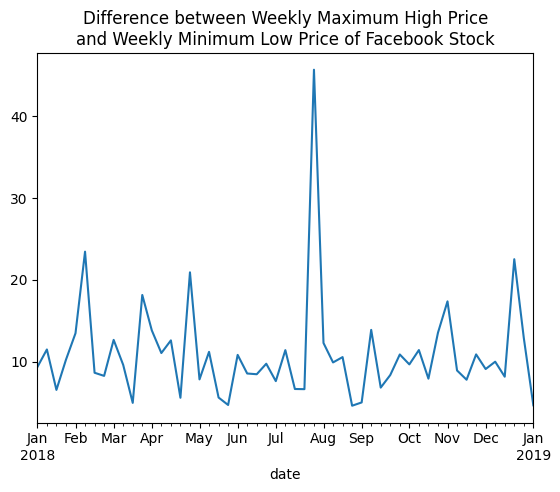

In [131]:
fb.resample('1W').agg(
    dict(high='max', low='min')
).assign(
    max_change_weekly=lambda x: x.high - x.low
).max_change_weekly.plot(
    title='Difference between Weekly Maximum High Price\n'
          'and Weekly Minimum Low Price of Facebook Stock'
)

In [132]:
# Calculate weekly high/low data
weekly_data = fb.resample('1W').agg(dict(high='max', low='min'))
weekly_data['max_change_weekly'] = weekly_data['high'] - weekly_data['low']

# Create Plotly line plot
fig = px.line(
    x=weekly_data.index,
    y=weekly_data['max_change_weekly'],
    title='Difference between Weekly Maximum High Price and Weekly Minimum Low Price of Facebook Stock',
    labels={'x': 'Date', 'y': 'Price Difference ($)'}
)

# Update layout for better appearance
fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Price Difference ($)',
    showlegend=False
)

# Add hover template for easier interpretation
fig.update_traces(
    hovertemplate='<b>Weekly Price Range</b><br>' +
                  'Date: %{x}<br>' +
                  'Price Difference: $%{y:.2f}<extra></extra>'
)

fig.show()

## Exercise 5
Plot the 14-day moving average of the daily change in new COVID-19 cases in Brazil, China, India, Italy, Spain, and the USA:

1. First use the `diff()` method from last chapter's time series section to calculate the day-over-day change in new cases, and then use `rolling()` to calculate the 14-day moving average.
2. Make 3 subplots: one for China; one for Spain and Italy; and one for Brazil, India, and the USA.

<Axes: xlabel='date'>

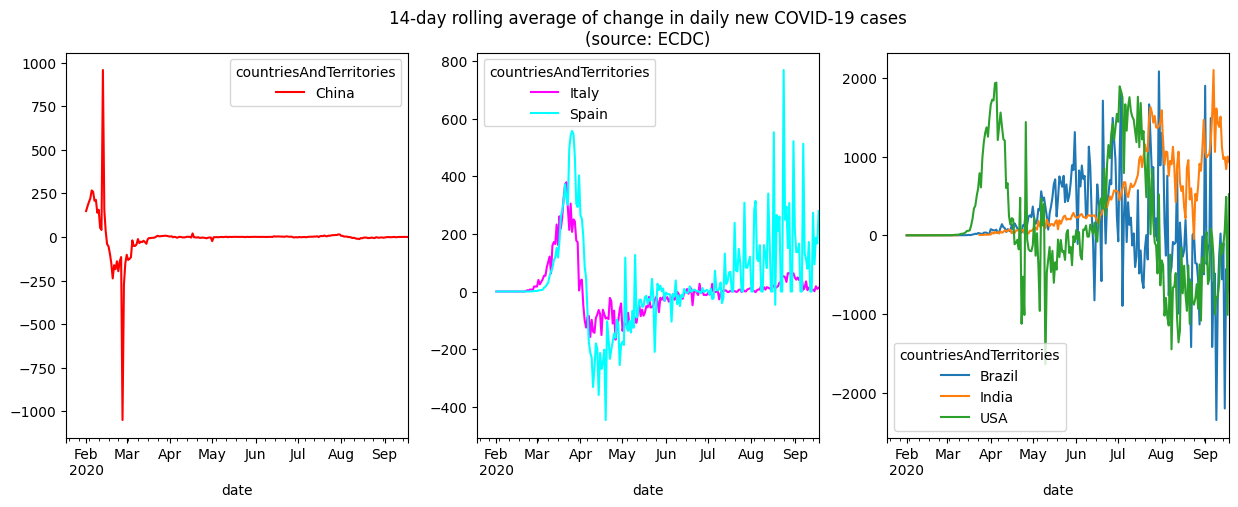

In [133]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

new_cases_rolling_average = covid.pivot_table(
    index=covid.index, columns=['countriesAndTerritories'], values='cases'
).apply(lambda x: x.diff().rolling(14).mean())

new_cases_rolling_average[['China']].plot(ax=axes[0], color='red')
new_cases_rolling_average[['Italy', 'Spain']].plot(
    ax=axes[1], color=['magenta', 'cyan'],
    title='14-day rolling average of change in daily new COVID-19 cases\n(source: ECDC)'
)
new_cases_rolling_average[['Brazil', 'India', 'USA']].plot(ax=axes[2])

In [134]:
# Calculate 14-day rolling average of daily change in COVID-19 cases
new_cases_rolling_average = covid.pivot_table(
    index=covid.index, columns=['countriesAndTerritories'], values='cases'
    # Difference | of the rolling 14 days | average for each country
).apply(lambda x: x.diff().rolling(14).mean())

# Create subplots using Plotly
fig = make_subplots(
    # Creating 3 subplots side by side
    rows=1, cols=3,
    subplot_titles=('China', 'Italy & Spain', 'Brazil, India & USA'),
    horizontal_spacing=0.08
)

# Subplot 1: China
fig.add_trace(
    go.Scatter(
        x=new_cases_rolling_average.index,
        y=new_cases_rolling_average['China'],
        mode='lines',
        name='China',
        line=dict(color='red'),
        hovertemplate='<b>China</b><br>Date: %{x}<br>Cases: %{y:.0f}<extra></extra>'
    ),
    row=1, col=1
)

# Subplot 2: Italy and Spain
fig.add_trace(
    go.Scatter(
        x=new_cases_rolling_average.index,
        y=new_cases_rolling_average['Italy'],
        mode='lines',
        name='Italy',
        line=dict(color='magenta'),
        hovertemplate='<b>Italy</b><br>Date: %{x}<br>Cases: %{y:.0f}<extra></extra>'
    ),
    row=1, col=2
)

fig.add_trace(
    go.Scatter(
        x=new_cases_rolling_average.index,
        y=new_cases_rolling_average['Spain'],
        mode='lines',
        name='Spain',
        line=dict(color='cyan'),
        hovertemplate='<b>Spain</b><br>Date: %{x}<br>Cases: %{y:.0f}<extra></extra>'
    ),
    row=1, col=2
)

# Subplot 3: Brazil, India, and USA
countries_group3 = ['Brazil', 'India', 'USA']
colors_group3 = ['green', 'orange', 'blue']

for country, color in zip(countries_group3, colors_group3):
    fig.add_trace(
        go.Scatter(
            x=new_cases_rolling_average.index,
            y=new_cases_rolling_average[country],
            mode='lines',
            name=country,
            line=dict(color=color),
            hovertemplate=f'<b>{country}</b><br>Date: %{{x}}<br>Cases: %{{y:.0f}}<extra></extra>'
        ),
        row=1, col=3
    )

# Update layout
fig.update_layout(
    title_text='14-day Rolling Average of Change in Daily New COVID-19 Cases (source: ECDC)',
    title_x=0.5,
    height=400,
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.1,
        xanchor="right",
        x=0.75
    )
)

# Update x and y axes
fig.update_xaxes(title_text="Date")
fig.update_yaxes(title_text="Change in Daily Cases")

fig.show()## Exercise 6


The negative changes could be due to data corrections or adjustments made by health authorities, such as reclassifying cases, removing duplicates, or correcting reporting errors.

These adjustments can lead to a decrease in the reported number of new cases on certain days.

It is interesting to see that China has had very few new cases since mid-2020, while the other countries have experienced multiple waves of infections.

It is sort of "controlled" much quicker than the other countries.

## Exercise 6
Using `matplotlib` and `pandas`, create two subplots side-by-side showing the effect that after-hours trading has had on Facebook's stock price:
1. The first subplot will contain a line plot of the daily difference between that day's opening price and the prior day's closing price (be sure to review last chapter's time series section for an easy way to do this).
2. The second subplot will be a bar plot showing the net effect this had monthly.
3. Bonus 1: Color the bars by whether they are gains in the stock price (green) or drops in the stock price (red).
4. Bonus 2: Modify the *x*-axis of the bar plot to show the three-letter abbreviation for the month.

<Axes: title={'center': 'After hours trading monthly effect'}, xlabel='date'>

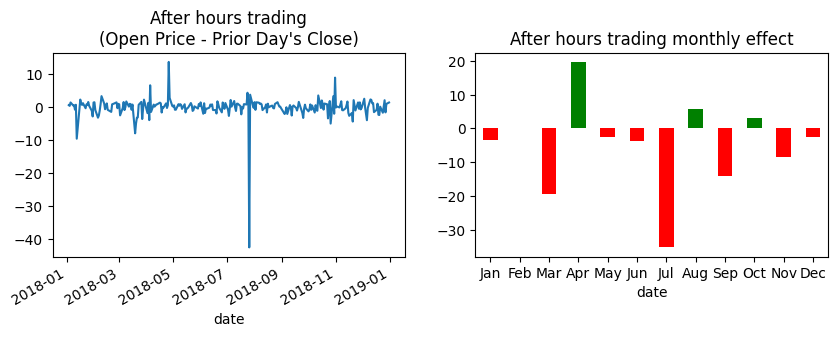

In [135]:
series = (fb.open - fb.close.shift())
monthly_effect = series.resample('ME').sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Plotting the first series
series.plot(
    ax=axes[0],
    title='After hours trading\n(Open Price - Prior Day\'s Close)'
)

# Format x-axis to show three-letter month abbreviation
monthly_effect.index = monthly_effect.index.strftime('%b')
monthly_effect.plot(
    ax=axes[1],
    kind='bar', 
    title='After hours trading monthly effect',
    # Coloring the bars by whether they are gains in the stock price (green) 
    # or drops in the stock price (red) using an np.where condition
    color=np.where(monthly_effect >= 0, 'g', 'r'),
    # Rotating the month labels
    rot=0
)

Using matplotlib is much simpler than plotly for this type of subplot. But plotly is more interactive.

Seems like Facebook experienced a significant dip in after-hours trading around March 2018. Also experienced a dip in July 2018 due to the Cambridge Analytica scandal ([Source](https://bipartisanpolicy.org/blog/cambridge-analytica-controversy)).

<hr>
<div>
    <a href="../../ch_05/3-pandas_plotting_module.ipynb">
        <button>&#8592; Chapter 4</button>
    </a>
    <a href="../../ch_06/1-introduction_to_seaborn.ipynb">
        <button style="float: right;">Chapter 6 &#8594;</button>
    </a>
</div>
<hr>